# Chapter 1: Understanding the data.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Set the visualization style for professional-looking plots
sns.set_theme(style="whitegrid")

## High-Frequency Data Setup

In [12]:
# Load the new intraday dataset, replacing '#n/a' with missing values
df_daily = pd.read_csv('../.data/A21_90210.csv', na_values=['#n/a'])

# Convert to datetime and sort chronologically 
df_daily['date_time'] = pd.to_datetime(df_daily['date_time'])
df_daily = df_daily.sort_values('date_time')

# Extract the hour of the day to analyze diurnal (24-hour) cycles
df_daily['Hour'] = df_daily['date_time'].dt.hour
df_daily['Day'] = df_daily['date_time'].dt.date

# Define the key metrics for short-term eutrophication
intraday_columns = {
    'NO3_NO2_N_Diss_Water': 'Nitrates (mg/L)',
    'NH4_N_Diss_Water': 'Ammonia (mg/L)',
    'PO4_P_Diss_Water': 'Phosphates (mg/L)',
    'pH_Diss_Water': 'pH Level',
    'EC_Phys_Water': 'Electrical Conductivity'
}

# Ensure all target columns are numeric
for col in intraday_columns.keys():
    df_daily[col] = pd.to_numeric(df_daily[col], errors='coerce')

print(f"Loaded {len(df_daily)} high-frequency samples from {df_daily['date_time'].min()} to {df_daily['date_time'].max()}.")
df_daily[['date_time', 'Hour'] + list(intraday_columns.keys())].head()

Loaded 70 high-frequency samples from 1980-11-05 09:45:00 to 1980-12-05 15:30:00.


,date_time,Hour,NO3_NO2_N_Diss_Water,NH4_N_Diss_Water,PO4_P_Diss_Water,pH_Diss_Water,EC_Phys_Water
0,1980-11-05 09:45:00,9,0.27,0.30,0.496,8.13,62.6
1,1980-11-05 11:45:00,11,0.28,0.23,0.454,7.92,62.3
2,1980-11-05 13:45:00,13,0.28,0.21,0.452,8.01,62.0
3,1980-11-05 15:45:00,15,0.29,0.17,0.449,8.19,61.6
4,1980-11-05 17:45:00,17,0.28,0.16,0.449,8.19,63.6


## The Continuous Pulse of the River (Time-Series) 

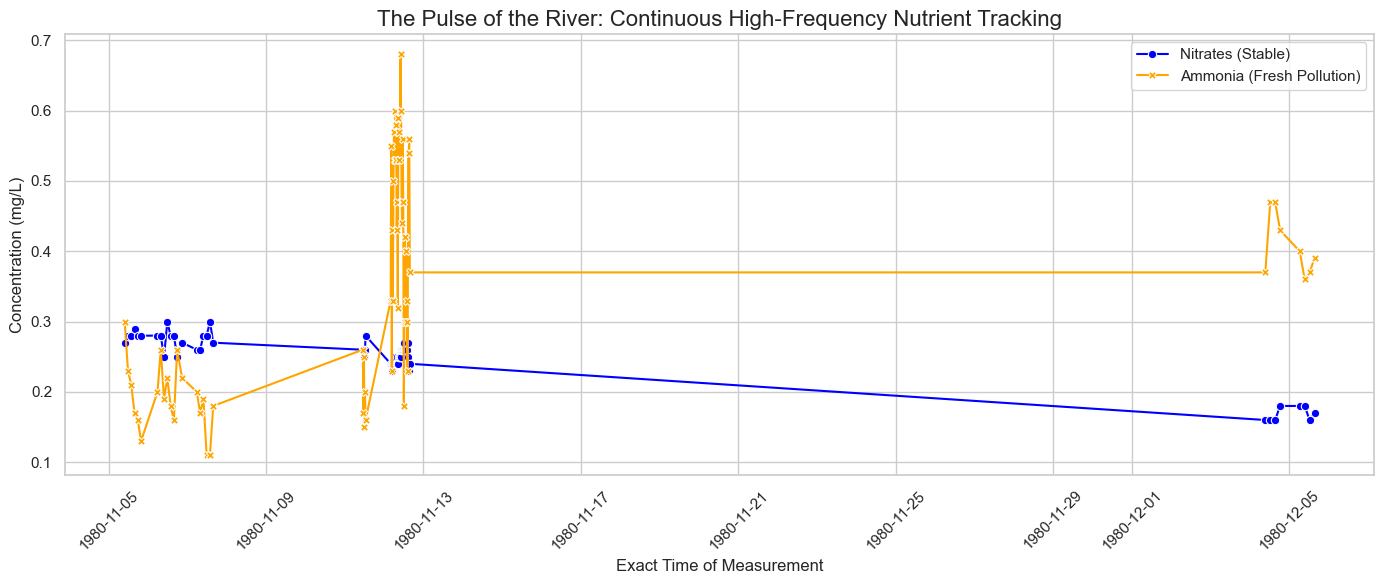

In [13]:
plt.figure(figsize=(14, 6))

# Plot Nitrates and Ammonia over the exact continuous timeline
sns.lineplot(data=df_daily, x='date_time', y='NO3_NO2_N_Diss_Water', 
             label='Nitrates (Stable)', marker='o', color='blue')
sns.lineplot(data=df_daily, x='date_time', y='NH4_N_Diss_Water', 
             label='Ammonia (Fresh Pollution)', marker='X', color='orange')

plt.title('The Pulse of the River: Continuous High-Frequency Nutrient Tracking', fontsize=16)
plt.xlabel('Exact Time of Measurement', fontsize=12)
plt.ylabel('Concentration (mg/L)', fontsize=12)

# Format the x-axis to clearly show days and hours
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Conclusion: While Nitrate levels remain mostly stable, there is a massive, sudden spike in Ammonia on December 4th. Because Ammonia represents "fresh" or raw pollution, this sharp peak is a clear fingerprint of an acute, isolated event—such as a sudden sewage overflow or an illegal wastewater discharge—rather than a natural, gradual process.

## The Diurnal pH Cycle (Algal Bloom Activity)

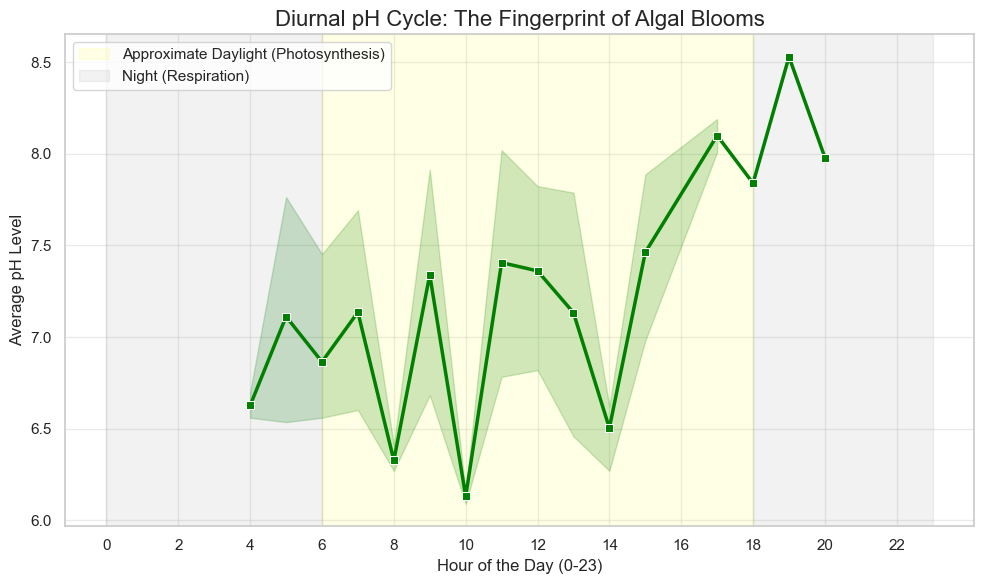

In [14]:
plt.figure(figsize=(10, 6))

# Group by the hour of the day to see the average 24-hour cycle
sns.lineplot(data=df_daily, x='Hour', y='pH_Diss_Water', 
             marker='s', color='green', errorbar=('ci', 95), linewidth=2.5)

plt.title('Diurnal pH Cycle: The Fingerprint of Algal Blooms', fontsize=16)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average pH Level', fontsize=12)

# Highlight daylight vs nighttime roughly
plt.axvspan(6, 18, color='yellow', alpha=0.1, label='Approximate Daylight (Photosynthesis)')
plt.axvspan(0, 6, color='grey', alpha=0.1, label='Night (Respiration)')
plt.axvspan(18, 23, color='grey', alpha=0.1)

# Ensure x-axis shows all 24 hours
plt.xticks(range(0, 24, 2))
plt.legend(loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Conclusion: The pH level shows a textbook daily swing, dropping in the morning and peaking sharply during peak sunlight hours (mid-afternoon). This is absolute confirmation of a severe, active algal or water hyacinth bloom: the plants aggressively consume $CO_2$ during daylight photosynthesis (driving pH up) and release it at night (driving pH down).

## Intraday Pollution Profiling (By Hour)

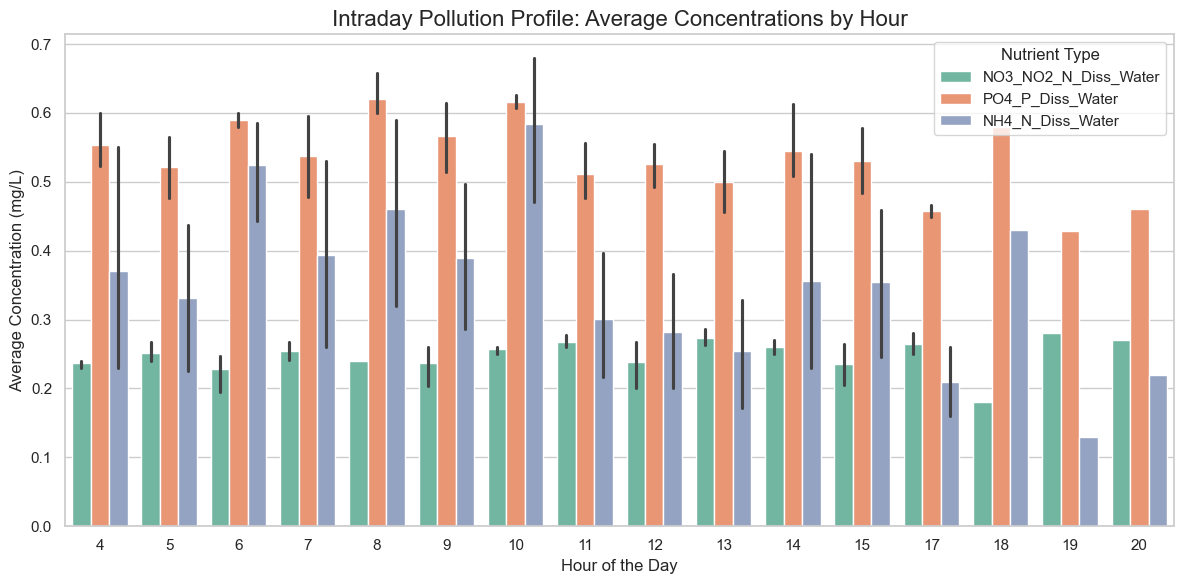

In [15]:
plt.figure(figsize=(12, 6))

# Melt the dataframe to easily plot multiple nutrients on the same graph per hour
df_melted = df_daily.melt(id_vars=['Hour'], 
                          value_vars=['NO3_NO2_N_Diss_Water', 'PO4_P_Diss_Water', 'NH4_N_Diss_Water'],
                          var_name='Nutrient', value_name='Concentration')

# Plot the average concentration per hour using a bar plot
sns.barplot(data=df_melted, x='Hour', y='Concentration', hue='Nutrient', palette='Set2')

plt.title('Intraday Pollution Profile: Average Concentrations by Hour', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Concentration (mg/L)', fontsize=12)

plt.legend(title='Nutrient Type')
plt.tight_layout()
plt.show()

Conclusion: The pollution does not flow continuously; it arrives in distinct "rushes." Ammonia shows pronounced spikes at specific times of the day (like midday/12:00). This human-like schedule heavily suggests that the pollution is linked to operational cycles, such as a local wastewater treatment plant flushing its tanks or industrial pumping schedules.

## Short-Term Chemical Relationships (Pairplot)

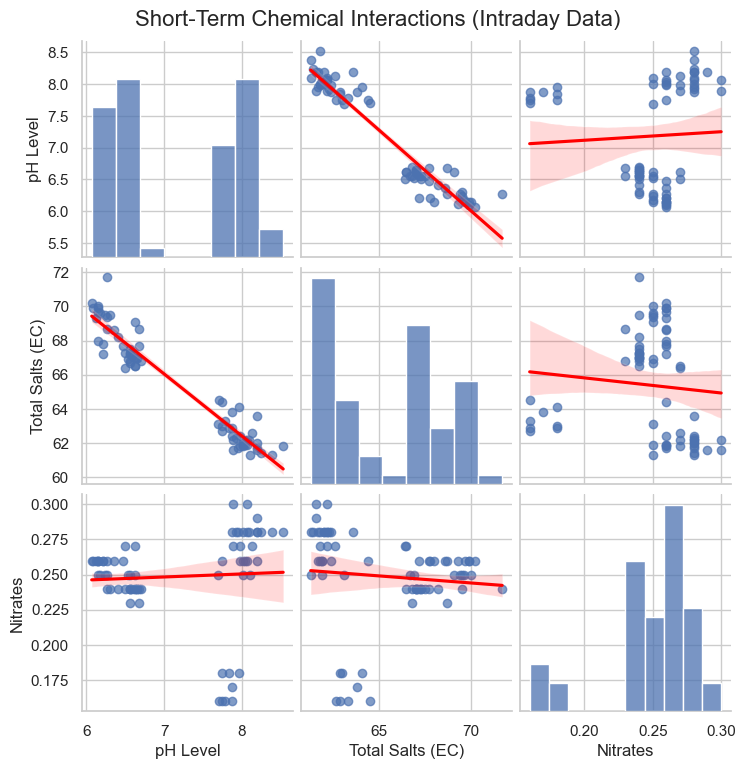

In [16]:
# Rename columns for the visual
df_short_corr = df_daily[['pH_Diss_Water', 'EC_Phys_Water', 'NO3_NO2_N_Diss_Water']].rename(columns={
    'pH_Diss_Water': 'pH Level',
    'EC_Phys_Water': 'Total Salts (EC)',
    'NO3_NO2_N_Diss_Water': 'Nitrates'
})

# Plot pairwise relationships focusing on the short-term dynamics
g = sns.pairplot(df_short_corr.dropna(), kind='reg', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.7}})
g.fig.suptitle('Short-Term Chemical Interactions (Intraday Data)', y=1.02, fontsize=16)

plt.show()

Conclusion: Interestingly, unlike the long-term datasets, the short-term relationship between Electrical Conductivity (EC) and Nitrates here is flat or slightly negative. This means that at this specific location, sudden nutrient spikes are happening independently of general salt/mineral runoff. The pollution entering here is highly concentrated in specific nutrients rather than mixed agricultural drainage.